# Data Visualization with Seaborn

### Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy

### Import Data

In [2]:
crash_df = sns.load_dataset('car_crashes')
crash_df.head()

,total,speeding,alcohol,not_distracted,no_previous,ins_premium,ins_losses,abbrev
0,18.8,7.332,5.640,18.048,15.040,784.55,145.08,AL
1,18.1,7.421,4.525,16.290,17.014,1053.48,133.93,AK
2,18.6,6.510,5.208,15.624,17.856,899.47,110.35,AZ
3,22.4,4.032,5.824,21.056,21.280,827.34,142.39,AR
4,12.0,4.200,3.360,10.920,10.680,878.41,165.63,CA


## Distribution Plots

## Distribution Plot

<Axes: xlabel='not_distracted', ylabel='Count'>

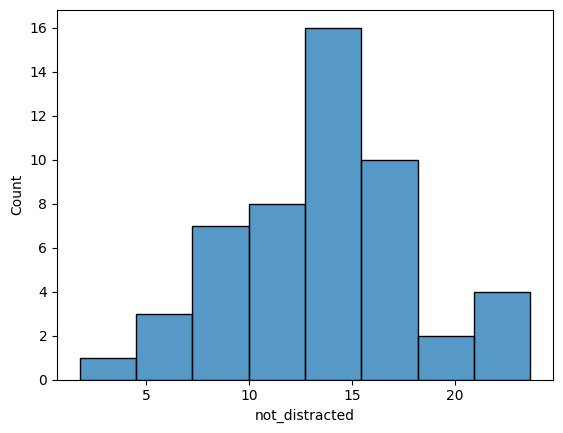

In [3]:
sns.histplot(crash_df['not_distracted'])

## Joint Plot

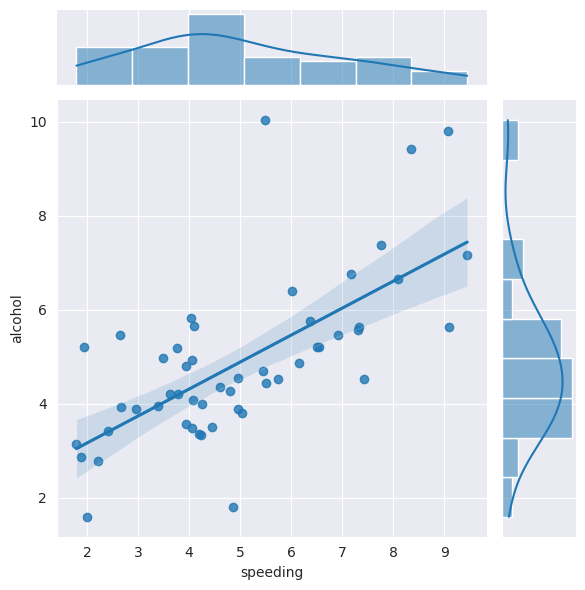

In [6]:
sns.jointplot(x=crash_df['speeding'],y= crash_df['alcohol'], kind='reg') #example for kind are (kde, hex, etc)

sns.set_style('darkgrid') #For styling (more are whitegrid, dark, tiks)

## KDE Plot

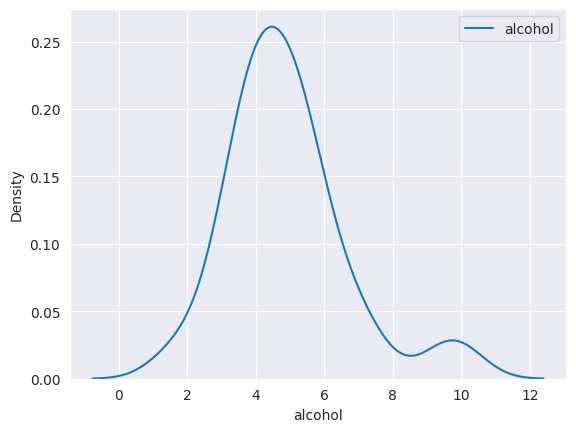

In [7]:
sns.kdeplot(crash_df['alcohol'], label='alcohol')
plt.legend()

## Pair Plot

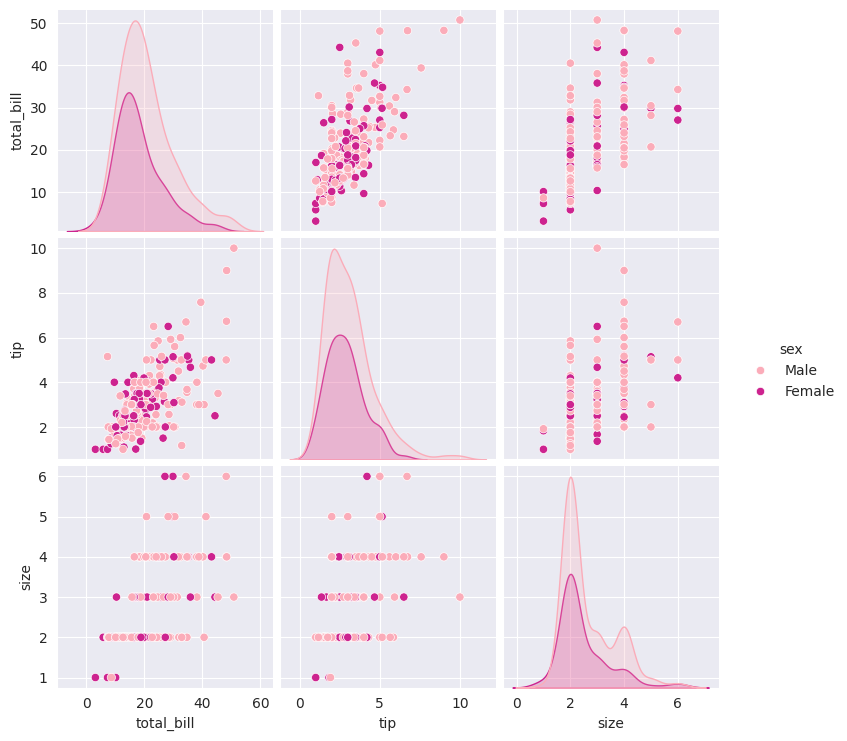

In [8]:
#sns.pairplot(crash_df)

tips = sns.load_dataset("tips")
sns.pairplot(tips, hue ='sex', palette= 'RdPu')

## Rug Plots

<Axes: xlabel='tip'>

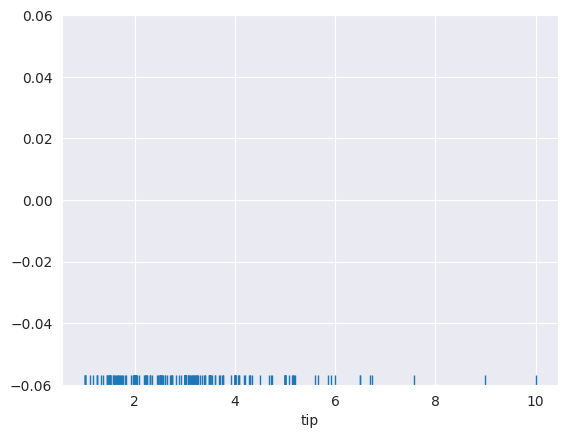

In [9]:
sns.rugplot(tips['tip']) #Denser  are indicates more values

## Styling

<Figure size 600x400 with 0 Axes>

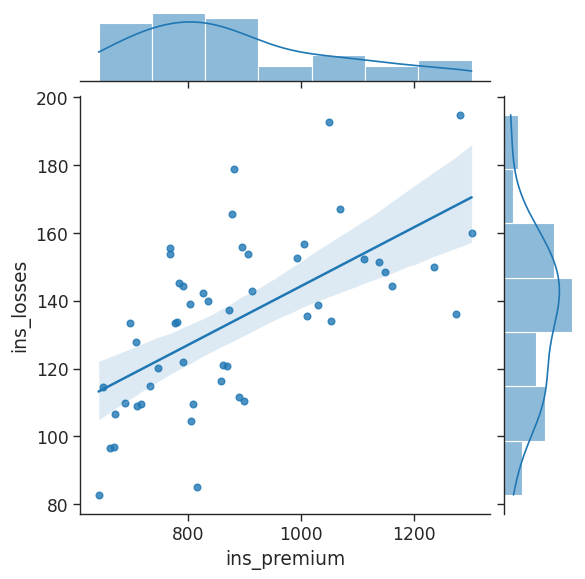

In [11]:
sns.set_style('ticks')
plt.figure(figsize=(6,4))
sns.set_context('paper', font_scale=1.4)
sns.jointplot(x=crash_df['ins_premium'],y=crash_df['ins_losses'], kind= 'reg')

## Categorical Plots

## Bar Plots

<Axes: xlabel='sex', ylabel='total_bill'>

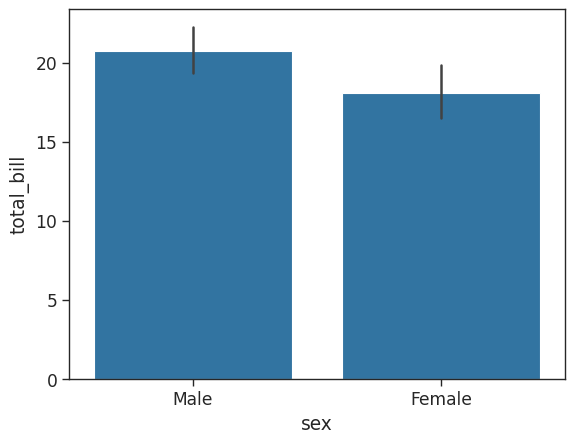

In [12]:
sns.barplot(x=tips['sex'],y=tips['total_bill'])

## Count Plot

<Axes: xlabel='sex', ylabel='count'>

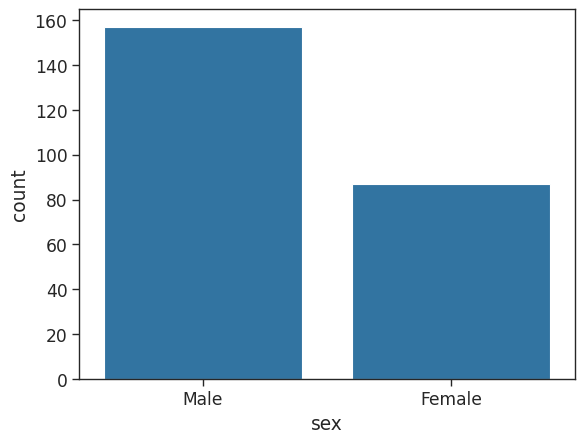

In [13]:
sns.countplot(x=tips['sex'])

## Box Plot

<Axes: xlabel='day', ylabel='total_bill'>

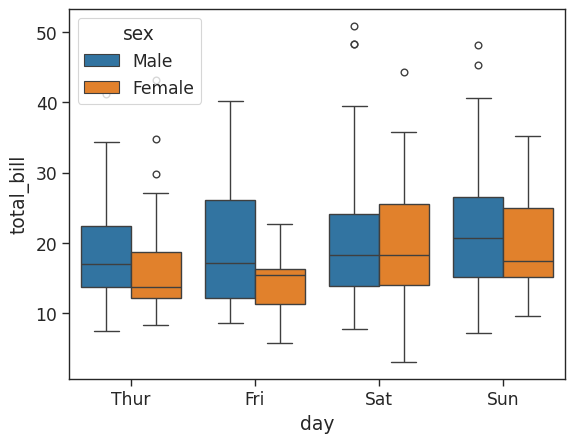

In [14]:
sns.boxplot(x=tips['day'],y=tips['total_bill'], hue=tips['sex'])

## Violin Plot

<Axes: xlabel='day', ylabel='total_bill'>

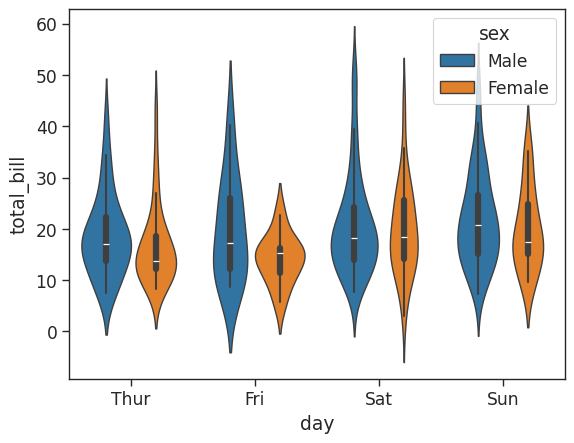

In [15]:
sns.violinplot(x=tips['day'],y=tips['total_bill'],hue=tips['sex'])

## Strip Plot

<Axes: xlabel='day', ylabel='total_bill'>

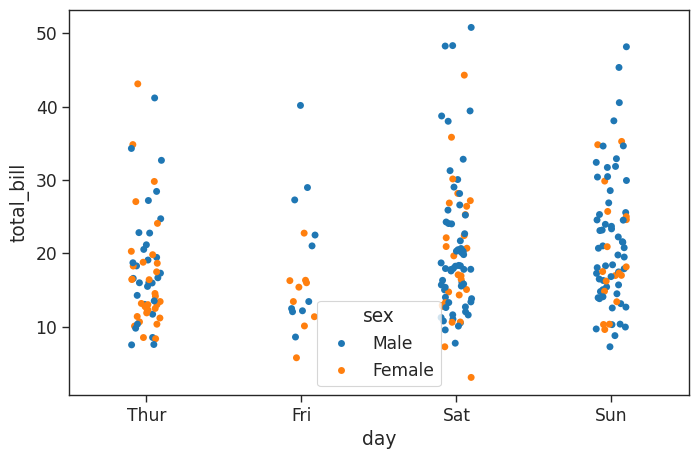

In [16]:
plt.figure(figsize=(8,5))
sns.stripplot(x=tips['day'],y=tips['total_bill'],jitter=True, hue=tips['sex'])

## Swarm Plot

<Axes: xlabel='day', ylabel='total_bill'>

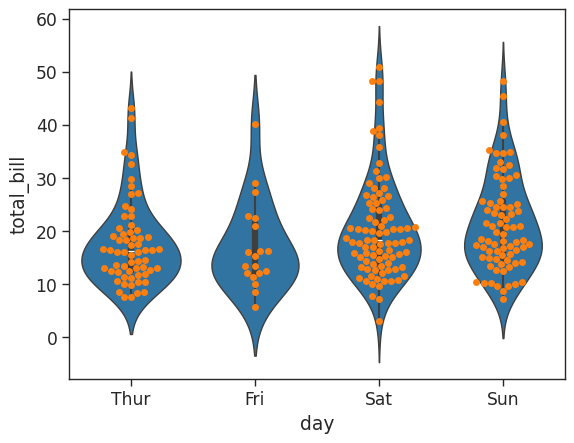

In [17]:
sns.violinplot(x=tips['day'],y=tips['total_bill'])
sns.swarmplot(x=tips['day'],y=tips['total_bill'])

## Palettes

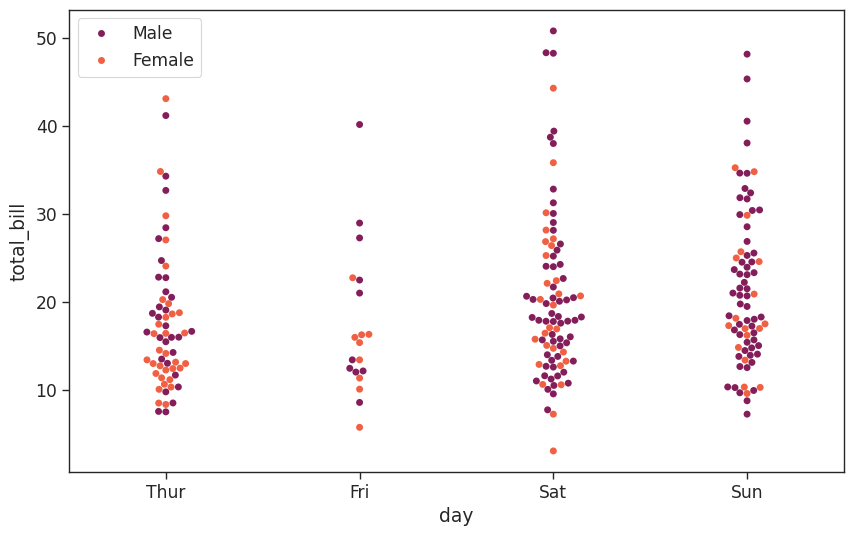

In [18]:
sns.set_style('ticks')
plt.figure(figsize=(10,6))
sns.set_context('paper', font_scale=1.4)
sns.swarmplot(x=tips['day'],y=tips['total_bill'], hue= tips['sex'], palette='rocket')
plt.legend(loc=0)

## Matrix Plots

## Heatmaps Plot

In [19]:
crash_df = crash_df.drop('abbrev',axis=1)
crash_df

,total,speeding,alcohol,not_distracted,no_previous,ins_premium,ins_losses
0,18.8,7.332,5.640,18.048,15.040,784.55,145.08
1,18.1,7.421,4.525,16.290,17.014,1053.48,133.93
2,18.6,6.510,5.208,15.624,17.856,899.47,110.35
3,22.4,4.032,5.824,21.056,21.280,827.34,142.39
4,12.0,4.200,3.360,10.920,10.680,878.41,165.63
5,13.6,5.032,3.808,10.744,12.920,835.50,139.91
6,10.8,4.968,3.888,9.396,8.856,1068.73,167.02
7,16.2,6.156,4.860,14.094,16.038,1137.87,151.48
8,5.9,2.006,1.593,5.900,5.900,1273.89,136.05
9,17.9,3.759,5.191,16.468,16.826,1160.13,144.18


<Axes: >

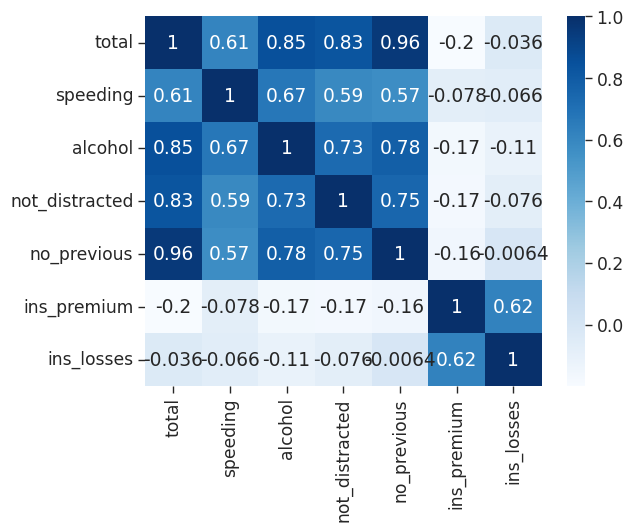

In [20]:
crash_mtx= crash_df.corr()# Making given dataframe to a correlation matrix
sns.heatmap(crash_mtx,annot=True, cmap='Blues')

/tmp/ipykernel_16390/3073271734.py:3: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  flights = flights.pivot_table(index='month', columns='year', values='passengers')


<Axes: xlabel='year', ylabel='month'>

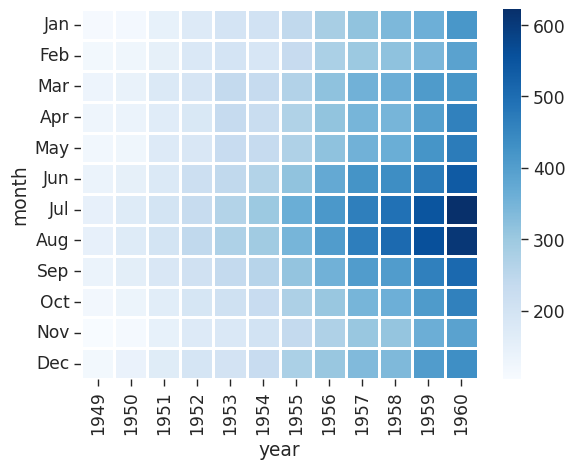

In [21]:
#Anorther way to make matrix of given data
flights = sns.load_dataset('flights')
flights = flights.pivot_table(index='month', columns='year', values='passengers')
sns.heatmap(flights,cmap='Blues',linecolor='w',linewidth=1)

## Cluster Map


In [22]:
iris= sns.load_dataset('iris')
species=iris.pop('species')

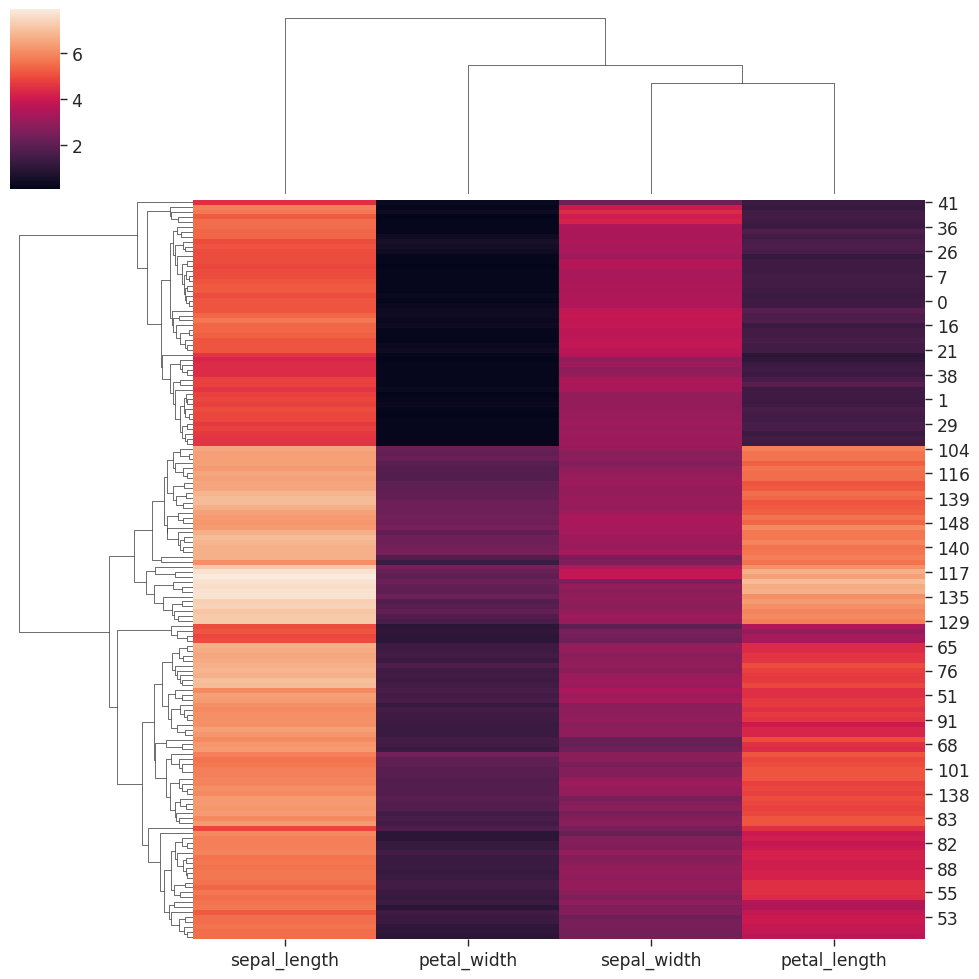

In [23]:
sns.clustermap(iris)

## PairGrid

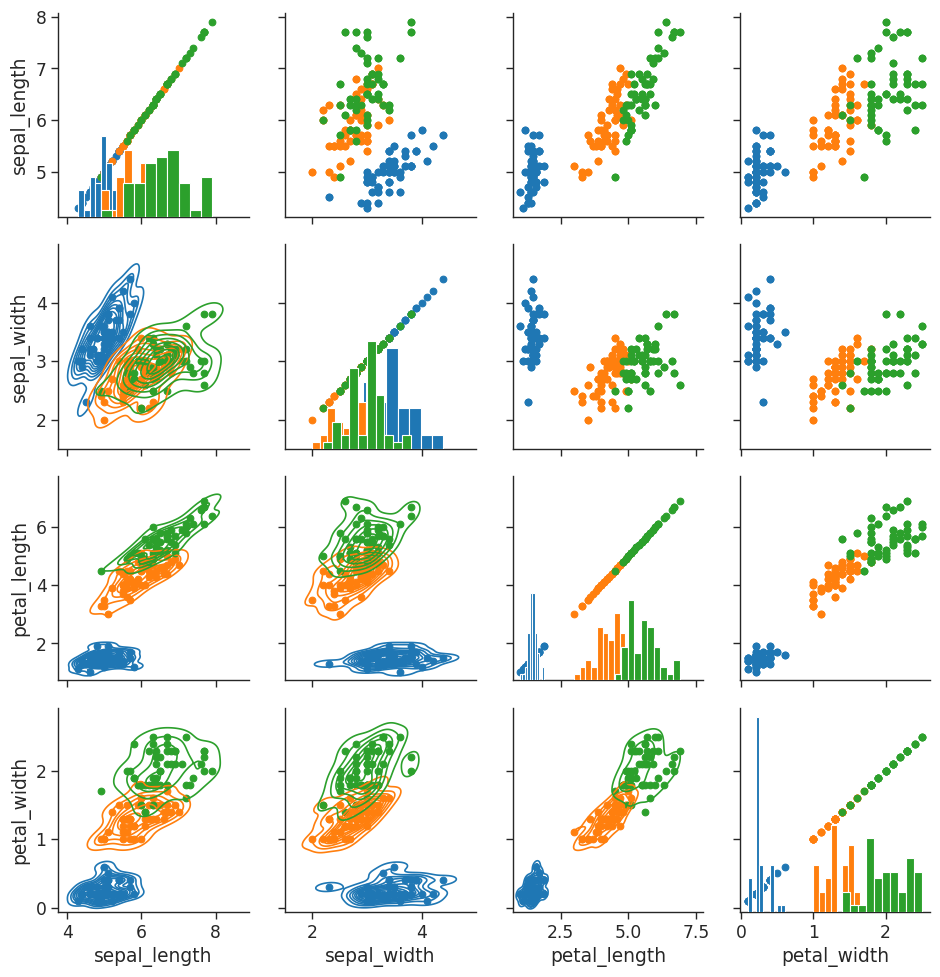

In [34]:
iris= sns.load_dataset('iris')
iris_g =sns.PairGrid(iris, hue='species')
iris_g.map(plt.scatter)
iris_g.map_diag(plt.hist)
#iris_g.map_offdiag(plt.scatter)
iris_g.map_upper(plt.scatter)
iris_g.map_lower(sns.kdeplot)

## Facet Grid

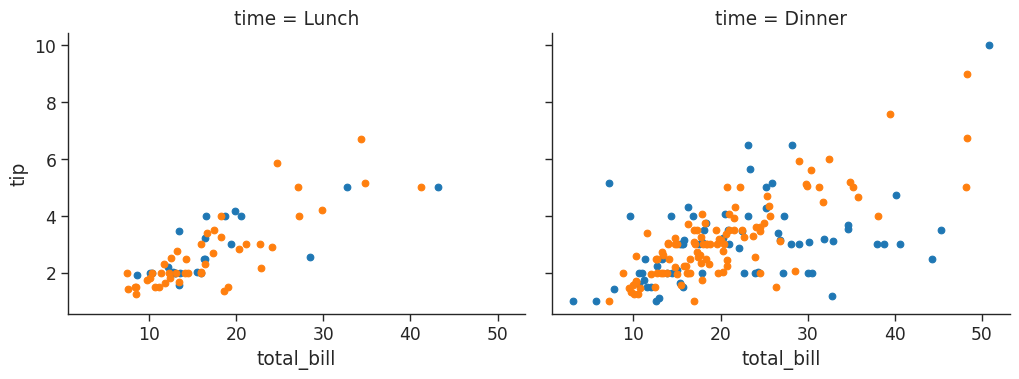

In [39]:
tips_fg = sns.FacetGrid(tips, col='time', hue='smoker', height=4, aspect= 1.3)
tips_fg.map(plt.scatter, 'total_bill', 'tip')

## Regression Plots

In [40]:
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


<Figure size 1000x600 with 0 Axes>

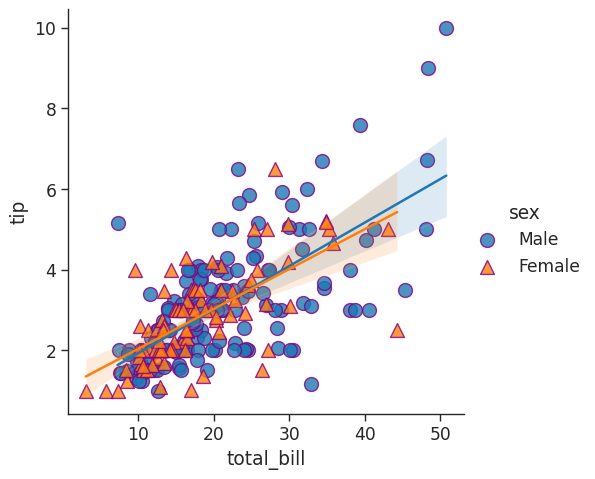

In [45]:
plt.figure(figsize=(10,6))
sns.set_context('paper', font_scale=1.4)
sns.lmplot(
    x='total_bill',
    y='tip',
    data=tips,
    hue='sex',
    markers=['o', '^'],
    scatter_kws={'s': 100,'edgecolor': 'purple'})

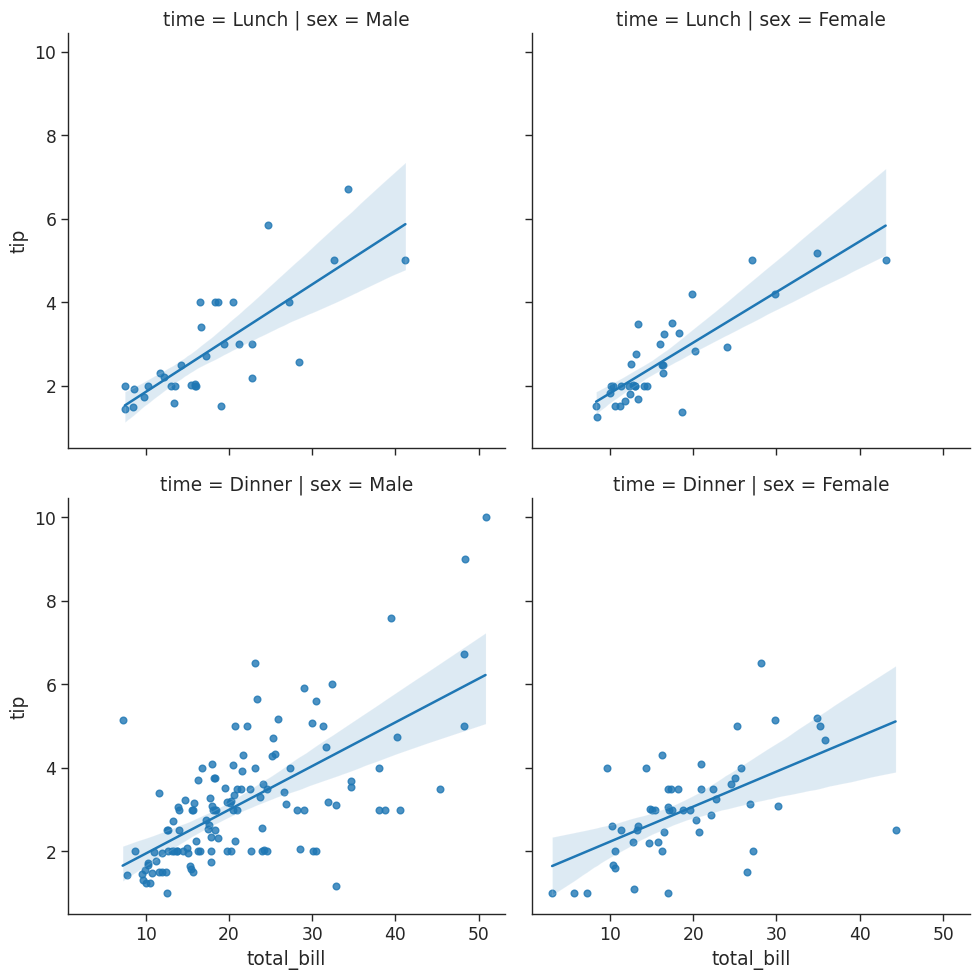

In [46]:
sns.lmplot(
    x='total_bill',
    y='tip',
    data=tips,col='sex', row='time')